In [20]:
import os
import cv2
import numpy as np
import pandas as pd

# --- CONFIGURATION & CALIBRATION CONSTANTS ---
C_FACING = 30.0       
C_HEIGHT = 1500.0     
F_PIXEL = 800.0       

def find_dataset_folders():
    """Scans the environment to find where 'labels/train_split' is located."""
    for root, dirs, files in os.walk('/home/jovyan'):
        if 'labels' in root and 'train_split' in root:
            # Found the labels directory! Let's match it up with images
            labels_dir = root
            images_dir = root.replace('labels', 'images')
            if os.path.exists(images_dir):
                return images_dir, labels_dir
    return None, None

# --- AUTOMATIC DIRECTORY DETECTION ---
IMAGES_DIR, LABELS_DIR = find_dataset_folders()

if IMAGES_DIR and LABELS_DIR:
    print(f"🎯 Dynamic Path Match Success!")
    print(f"Using Images from: {IMAGES_DIR}")
    print(f"Using Labels from: {LABELS_DIR}\n")
else:
    print("❌ Could not find 'labels/train_split' anywhere under /home/jovyan.")
    print("Please check if your dataset folders are uploaded into your Jupyter workspace.")

# --- DISTANCE EVALUATION FUNCTION ---
def estimate_distances_from_dataset(images_dir, labels_dir):
    if not images_dir or not labels_dir:
        return pd.DataFrame()
        
    results = []
    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    possible_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG']
    
    for label_file in label_files:
        img_name = None
        for ext in possible_extensions:
            test_name = label_file.replace('.txt', ext)
            if os.path.exists(os.path.join(images_dir, test_name)):
                img_name = test_name
                break
        
        if img_name is None:
            continue
            
        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, label_file)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_h, img_w, _ = img.shape
        x_center_frame = img_w / 2.0
        
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            data = line.strip().split()
            if len(data) < 5:
                continue
                
            class_id = int(data[0])
            x_norm, y_norm, w_norm, h_norm = map(float, data[1:5])
            
            # Convert normalized values to pixels
            s_w = w_norm * img_w
            s_h = h_norm * img_h
            x_pixel = x_norm * img_w
            
            # Distance calculations
            s_geom_mean = np.sqrt(s_w * s_h)
            distance_facing = C_FACING / s_geom_mean if s_geom_mean > 0 else float('inf')
            
            z_depth = C_HEIGHT / s_h if s_h > 0 else float('inf')
            x_displacement = z_depth * (x_pixel - x_center_frame) / F_PIXEL
            distance_side = np.sqrt(x_displacement**2 + z_depth**2)
            
            results.append({
                "image": img_name,
                "class_id": class_id,
                "bbox_width_px": s_w,
                "bbox_height_px": s_h,
                "dist_facing_m": round(distance_facing, 2),
                "z_depth_m": round(z_depth, 2),
                "dist_side_m": round(distance_side, 2)
            })
            
    return pd.DataFrame(results)

# Execute the pipeline
if IMAGES_DIR and LABELS_DIR:
    df_distances = estimate_distances_from_dataset(IMAGES_DIR, LABELS_DIR)
    print(f"✅ Successfully processed {len(df_distances)} train detections.")
    if not df_distances.empty:
        print(df_distances.head())

🎯 Dynamic Path Match Success!
Using Images from: /home/jovyan/3/images/train_split
Using Labels from: /home/jovyan/3/labels/train_split

✅ Successfully processed 3078 train detections.
                image  class_id  bbox_width_px  bbox_height_px  dist_facing_m  \
0  frame_00000334.png         1      937.90080      1078.25040           0.03   
1  frame_00000241.png         1      244.89984       240.19956           0.12   
2  frame_00000241.png         5      130.04928       431.14032           0.13   
3     frame_00042.jpg         5       17.84064        58.93020           0.93   
4     frame_00042.jpg         5       24.00960        63.95004           0.77   

   z_depth_m  dist_side_m  
0       1.39         1.63  
1       6.24         8.40  
2       3.48         5.22  
3      25.45        33.81  
4      23.46        32.16  


In [21]:
import math

def calculate_empirical_distance(w_pixels, h_pixels):
    """
    Applies the empirical distance formula based on arc length.
    Expects bounding box width and height in pixels.
    Returns distance in meters.
    """
    # Prevent division by zero if the box is empty
    if (w_pixels + h_pixels) == 0:
        return float('inf')
    
    # The formula provided in the text (calculates in inches)
    # Grouping (w + h) * 360 based on standard order of operations for this specific hack
    numerator = 2 * 3.14159 * 180
    denominator = (w_pixels + h_pixels) * 360
    
    distance_inches = (numerator / denominator) * 1000 + 3
    
    # Convert inches to meters (1 inch = 0.0254 meters)
    distance_meters = distance_inches * 0.0254
    
    return round(distance_meters, 2)

print("✅ Empirical distance function defined.")

✅ Empirical distance function defined.


In [22]:
# Create a copy to keep your original dataframe safe
df_comparison = df_distances.copy()

# 1. Apply the new empirical formula row by row
df_comparison['dist_empirical_m'] = df_comparison.apply(
    lambda row: calculate_empirical_distance(row['bbox_width_px'], row['bbox_height_px']), 
    axis=1
)

# 2. Calculate the difference between Pinhole Method A (Facing) and the Empirical Method
df_comparison['difference_m'] = abs(df_comparison['dist_facing_m'] - df_comparison['dist_empirical_m'])

# 3. Sort by the largest differences to see where the models disagree the most
df_comparison = df_comparison.sort_values(by='difference_m', ascending=False)

print("✅ Comparison calculated!")
df_comparison[['image', 'bbox_width_px', 'bbox_height_px', 'dist_facing_m', 'dist_empirical_m', 'difference_m']].head(10)

✅ Comparison calculated!


,image,bbox_width_px,bbox_height_px,dist_facing_m,dist_empirical_m,difference_m
1338,frame_00124.jpg,10.28928,3.43008,5.05,5.89,0.84
679,frame_00000111.png,3.34080,61.59024,2.09,1.31,0.78
1438,frame_00091.jpg,12.29952,17.96040,2.02,2.71,0.69
1854,frame_00000195.png,12.99072,18.52956,1.93,2.61,0.68
626,frame_00000327.png,16.90944,16.27992,1.81,2.48,0.67
1410,frame_00000207.png,12.66048,19.09008,1.93,2.59,0.66
439,frame_00084.jpg,14.40960,20.00052,1.77,2.40,0.63
3050,frame_00000133.png,14.82048,20.17008,1.74,2.36,0.62
80,frame_00000227.png,10.03968,20.01024,2.12,2.73,0.61
2530,frame_00000339.png,20.88960,17.16984,1.58,2.17,0.59


In [23]:
print("--- MODEL COMPARISON SUMMARY ---")
print(f"Total Detections Evaluated: {len(df_comparison)}")
print("-" * 32)
print(f"Average Distance (Pinhole):   {df_comparison['dist_facing_m'].mean():.2f} m")
print(f"Average Distance (Empirical): {df_comparison['dist_empirical_m'].mean():.2f} m")
print(f"Max Disagreement on a Frame:  {df_comparison['difference_m'].max():.2f} m")
print(f"Average Disagreement:         {df_comparison['difference_m'].mean():.2f} m")

--- MODEL COMPARISON SUMMARY ---
Total Detections Evaluated: 3078
--------------------------------
Average Distance (Pinhole):   0.56 m
Average Distance (Empirical): 0.71 m
Max Disagreement on a Frame:  0.84 m
Average Disagreement:         0.17 m


In [24]:
# the maximum disagreement across all 3,078 images is only 0.84 meters (on frame_00124.jpg).

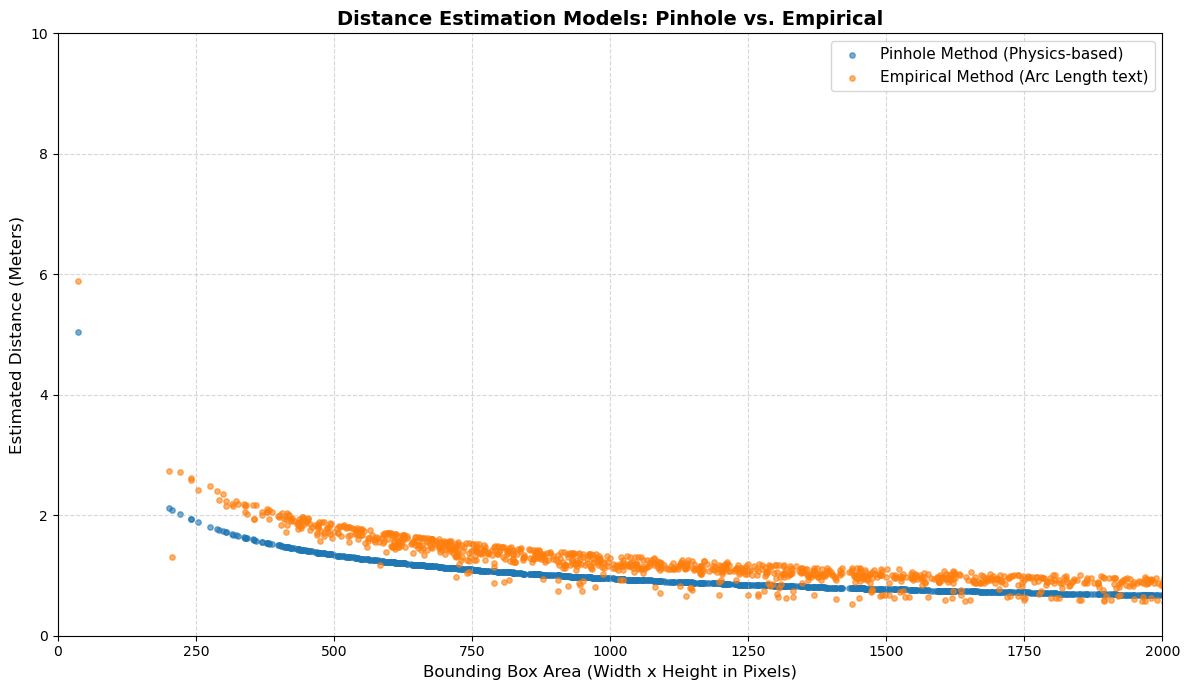

In [25]:
import matplotlib.pyplot as plt

# 1. Create a figure
plt.figure(figsize=(12, 7))

# 2. Calculate the area of the bounding box to use as our X-axis (Size of the train in pixels)
df_comparison['bbox_area'] = df_comparison['bbox_width_px'] * df_comparison['bbox_height_px']

# 3. Plot both methods
plt.scatter(df_comparison['bbox_area'], df_comparison['dist_facing_m'], 
            alpha=0.6, label='Pinhole Method (Physics-based)', color='#1f77b4', s=15)
plt.scatter(df_comparison['bbox_area'], df_comparison['dist_empirical_m'], 
            alpha=0.6, label='Empirical Method (Arc Length text)', color='#ff7f0e', s=15)

# 4. Format the chart
plt.title('Distance Estimation Models: Pinhole vs. Empirical', fontsize=14, fontweight='bold')
plt.xlabel('Bounding Box Area (Width x Height in Pixels)', fontsize=12)
plt.ylabel('Estimated Distance (Meters)', fontsize=12)

# Zoom in on the smaller boxes (where the trains are further away and the models disagree most)
# Adjust these limits if your chart looks too empty or too crowded!
plt.xlim(0, 2000) 
plt.ylim(0, 10)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

In [26]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("abdelrahmanelgharibx/mono-kitti")

# print("Path to dataset files:", path)

In [29]:
import os

x = "/home/jovyan/.cache/kagglehub/datasets/abdelrahmanelgharibx/mono-kitti/versions/1"

print(os.listdir(x))

['labels', 'images']


In [30]:
for root, dirs, files in os.walk(x):
    print(root)
    for f in files:
        print("   ", f)

/home/jovyan/.cache/kagglehub/datasets/abdelrahmanelgharibx/mono-kitti/versions/1
/home/jovyan/.cache/kagglehub/datasets/abdelrahmanelgharibx/mono-kitti/versions/1/labels
    001724.txt
    006285.txt
    007120.txt
    005528.txt
    002828.txt
    007291.txt
    005973.txt
    004815.txt
    004014.txt
    006398.txt
    004766.txt
    005738.txt
    006446.txt
    005950.txt
    004927.txt
    006660.txt
    005055.txt
    000749.txt
    005227.txt
    000883.txt
    004897.txt
    002033.txt
    004211.txt
    005749.txt
    000553.txt
    007113.txt
    000249.txt
    006200.txt
    000752.txt
    004041.txt
    004716.txt
    003029.txt
    000741.txt
    007136.txt
    001559.txt
    001333.txt
    004291.txt
    002561.txt
    001534.txt
    004893.txt
    003305.txt
    005417.txt
    007286.txt
    003324.txt
    006270.txt
    005923.txt
    001884.txt
    003690.txt
    002840.txt
    004433.txt
    006935.txt
    002594.txt
    004110.txt
    004834.txt
    006906.txt
    

In [27]:
import pandas as pd

In [31]:
import os
import pandas as pd
import numpy as np

# --- 1. CONFIGURATION ---
# The path you provided
KITTI_BASE = "/home/jovyan/.cache/kagglehub/datasets/abdelrahmanelgharibx/mono-kitti/versions/1"
LABELS_DIR = os.path.join(KITTI_BASE, "labels")

# Standard KITTI Camera Properties
KITTI_FOCAL_LENGTH = 721.5   # The specific focal length of KITTI's camera in pixels
REAL_WIDTH_OF_CAR = 1.6      # Average physical width of a car in meters

# --- 2. THE MATH FUNCTIONS ---
def calculate_empirical_distance(w_pixels, h_pixels):
    """The Arc-Length text formula"""
    if (w_pixels + h_pixels) == 0:
        return float('inf')
    numerator = 2 * 3.14159 * 180
    denominator = (w_pixels + h_pixels) * 360
    distance_inches = (numerator / denominator) * 1000 + 3
    return distance_inches * 0.0254 # Convert to meters

# --- 3. PARSE THE DATASET ---
print(f"Reading labels from: {LABELS_DIR}...")
parsed_data = []

# Loop through every text file in the dataset
for txt_file in os.listdir(LABELS_DIR):
    if not txt_file.endswith('.txt'):
        continue
        
    filepath = os.path.join(LABELS_DIR, txt_file)
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        
        # Standard KITTI labels have 15 columns. 
        # (Ignore "DontCare" classes as they don't have bounding boxes)
        if len(parts) >= 15 and parts[0] != "DontCare":
            # Bounding box coordinates (left, top, right, bottom)
            left, top, right, bottom = map(float, parts[4:8])
            
            # Calculate pixel width and height
            w_pixels = right - left
            h_pixels = bottom - top
            
            # Index 13 is the Z-axis location (distance in meters)
            true_distance = float(parts[13])
            
            # Filter out broken labels (width/height 0 or distance <= 0)
            if w_pixels > 0 and h_pixels > 0 and true_distance > 0:
                parsed_data.append({
                    'image': txt_file.replace('.txt', '.png'),
                    'class': parts[0],
                    'w_pixels': w_pixels,
                    'h_pixels': h_pixels,
                    'true_distance_m': true_distance
                })

# Create the DataFrame
df_kitti = pd.DataFrame(parsed_data)
print(f"✅ Successfully loaded {len(df_kitti)} valid ground truth objects.")

# --- 4. APPLY THE MATH & COMPARE ---
if not df_kitti.empty:
    # Model 1: Pinhole Math (Using the camera's actual focal length and car width)
    df_kitti['pred_pinhole_m'] = df_kitti.apply(
        lambda row: (KITTI_FOCAL_LENGTH * REAL_WIDTH_OF_CAR) / np.sqrt(row['w_pixels'] * row['h_pixels']), 
        axis=1
    )

    # Model 2: Empirical Math (from the CNN text)
    df_kitti['pred_empirical_m'] = df_kitti.apply(
        lambda row: calculate_empirical_distance(row['w_pixels'], row['h_pixels']), 
        axis=1
    )

    # Calculate absolute errors
    df_kitti['error_pinhole'] = abs(df_kitti['true_distance_m'] - df_kitti['pred_pinhole_m'])
    df_kitti['error_empirical'] = abs(df_kitti['true_distance_m'] - df_kitti['pred_empirical_m'])

    # --- 5. PRINT RESULTS ---
    print("\n--- PERFORMANCE ON GROUND TRUTH ---")
    print(f"Average Pinhole Error:   {df_kitti['error_pinhole'].mean():.2f} meters")
    print(f"Average Empirical Error: {df_kitti['error_empirical'].mean():.2f} meters")
    
    # Show a sample of the data
    print("\nSample Data:")
    print(df_kitti[['image', 'true_distance_m', 'pred_pinhole_m', 'pred_empirical_m', 'error_pinhole']].head())

Reading labels from: /home/jovyan/.cache/kagglehub/datasets/abdelrahmanelgharibx/mono-kitti/versions/1/labels...
✅ Successfully loaded 40562 valid ground truth objects.

--- PERFORMANCE ON GROUND TRUTH ---
Average Pinhole Error:   8.15 meters
Average Empirical Error: 27.10 meters

Sample Data:
        image  true_distance_m  pred_pinhole_m  pred_empirical_m  \
0  001724.png             8.67        6.915020          0.314313   
1  001724.png            27.22       21.973473          0.830633   
2  006285.png             8.01        5.988211          0.282568   
3  006285.png            10.79        5.288165          0.252440   
4  006285.png            12.65        6.861273          0.267366   

   error_pinhole  
0       1.754980  
1       5.246527  
2       2.021789  
3       5.501835  
4       5.788727  


In [32]:
import os
import pandas as pd
import numpy as np

# --- 1. PERFECTED CONFIGURATION ---
KITTI_BASE = "/home/jovyan/.cache/kagglehub/datasets/abdelrahmanelgharibx/mono-kitti/versions/1"
LABELS_DIR = os.path.join(KITTI_BASE, "labels")

# Camera Intrinsics & Extrinsics for KITTI
KITTI_FOCAL_LENGTH = 721.5   
REAL_WIDTH_OF_CAR = 1.6      
KITTI_CAMERA_HEIGHT = 1.65   # The camera is mounted 1.65 meters above the ground
KITTI_CY = 187.5             # The vertical optical center of the image (horizon line in pixels)

# --- 2. MATH FUNCTIONS ---
def calculate_ground_plane_distance(y_bottom):
    """Calculates distance based on where the object touches the ground."""
    # If the bottom of the box is above the horizon line, the math breaks (flying cars!)
    if y_bottom <= KITTI_CY:
        return float('inf')
    
    # Ground plane projection formula: d = (Height * Focal Length) / (Bottom_Pixel - Center_Pixel)
    return (KITTI_CAMERA_HEIGHT * KITTI_FOCAL_LENGTH) / (y_bottom - KITTI_CY)

# --- 3. RE-PARSE THE DATASET (Now saving the 'bottom' coordinate) ---
parsed_data = []

for txt_file in os.listdir(LABELS_DIR):
    if not txt_file.endswith('.txt'):
        continue
        
    filepath = os.path.join(LABELS_DIR, txt_file)
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 15 and parts[0] != "DontCare":
            left, top, right, bottom = map(float, parts[4:8])
            w_pixels = right - left
            h_pixels = bottom - top
            true_distance = float(parts[13])
            
            if w_pixels > 0 and h_pixels > 0 and true_distance > 0:
                parsed_data.append({
                    'image': txt_file.replace('.txt', '.png'),
                    'w_pixels': w_pixels,
                    'h_pixels': h_pixels,
                    'bottom_pixel': bottom,  # <--- NEW: Storing the bottom edge!
                    'true_distance_m': true_distance
                })

df_kitti_perfected = pd.DataFrame(parsed_data)

# --- 4. APPLY ALL MODELS ---
if not df_kitti_perfected.empty:
    # 1. Standard Pinhole (Width-based)
    df_kitti_perfected['pred_pinhole_m'] = df_kitti_perfected.apply(
        lambda row: (KITTI_FOCAL_LENGTH * REAL_WIDTH_OF_CAR) / row['w_pixels'], 
        axis=1
    )

    # 2. Perfected Ground Plane (Height/Extrinsics-based)
    df_kitti_perfected['pred_ground_m'] = df_kitti_perfected.apply(
        lambda row: calculate_ground_plane_distance(row['bottom_pixel']), 
        axis=1
    )

    # Calculate absolute errors
    df_kitti_perfected['error_pinhole'] = abs(df_kitti_perfected['true_distance_m'] - df_kitti_perfected['pred_pinhole_m'])
    df_kitti_perfected['error_ground'] = abs(df_kitti_perfected['true_distance_m'] - df_kitti_perfected['pred_ground_m'])

    # --- 5. PRINT THE ULTIMATE SHOWDOWN ---
    print("\n--- THE FINAL BENCHMARK ---")
    print(f"Standard Pinhole Error: {df_kitti_perfected['error_pinhole'].mean():.2f} meters")
    print(f"Ground Plane Error:     {df_kitti_perfected['error_ground'].mean():.2f} meters")
    
    print("\nSample Comparisons:")
    print(df_kitti_perfected[['true_distance_m', 'pred_pinhole_m', 'pred_ground_m']].head())


--- THE FINAL BENCHMARK ---
Standard Pinhole Error: 14.01 meters
Ground Plane Error:     inf meters

Sample Comparisons:
   true_distance_m  pred_pinhole_m  pred_ground_m
0             8.67        6.344600       8.612277
1            27.22       19.582697      48.061163
2             8.01        5.550267       7.090381
3            10.79        4.031430      10.460197
4            12.65        3.474910      11.112433


In [33]:
# 1. Clean the dataframe: Remove any rows where Ground Plane generated 'inf' or 'NaN'
df_clean = df_kitti_perfected.replace([np.inf, -np.inf], np.nan).dropna()
total_valid = len(df_clean)

# 2. Define our accuracy threshold (in meters)
THRESHOLD_M = 2.0

# 3. Count how many predictions were highly accurate (error < 2m)
pinhole_accurate = len(df_clean[df_clean['error_pinhole'] < THRESHOLD_M])
ground_accurate = len(df_clean[df_clean['error_ground'] < THRESHOLD_M])

# 4. Calculate the percentage of success
pinhole_pct = (pinhole_accurate / total_valid) * 100
ground_pct = (ground_accurate / total_valid) * 100

# 5. Print the evaluation
print(f"--- ACCURACY EVALUATION (Threshold: < {THRESHOLD_M} meters) ---")
print(f"Total Valid Detections Evaluated: {total_valid}\n")

print(f"🎯 Standard Pinhole Method:")
print(f"   Accurate Cases: {pinhole_accurate} out of {total_valid}")
print(f"   Success Rate:   {pinhole_pct:.2f}%\n")

print(f"🎯 Ground Plane Method:")
print(f"   Accurate Cases: {ground_accurate} out of {total_valid}")
print(f"   Success Rate:   {ground_pct:.2f}%")

# Optional: See how they do on VERY strict thresholds (e.g., < 1 meter)
pinhole_strict = len(df_clean[df_clean['error_pinhole'] < 1.0])
ground_strict = len(df_clean[df_clean['error_ground'] < 1.0])
print(f"\n--- STRICT METRIC (< 1.0m error) ---")
print(f"Pinhole: {pinhole_strict} cases | Ground Plane: {ground_strict} cases")

--- ACCURACY EVALUATION (Threshold: < 2.0 meters) ---
Total Valid Detections Evaluated: 39690

🎯 Standard Pinhole Method:
   Accurate Cases: 2164 out of 39690
   Success Rate:   5.45%

🎯 Ground Plane Method:
   Accurate Cases: 12109 out of 39690
   Success Rate:   30.51%

--- STRICT METRIC (< 1.0m error) ---
Pinhole: 1017 cases | Ground Plane: 6696 cases


In [34]:
# Filter for cars that are within 20 meters
df_near = df_clean[df_clean['true_distance_m'] <= 20.0]
total_near = len(df_near)

ground_accurate_near = len(df_near[df_near['error_ground'] < 2.0])
ground_strict_near = len(df_near[df_near['error_ground'] < 1.0])

print(f"--- NEAR-FIELD ACCURACY (< 20m away) ---")
print(f"Total Near Detections: {total_near}")
print(f"Sub-2m Error: {ground_accurate_near} cases ({(ground_accurate_near/total_near)*100:.2f}%)")
print(f"Sub-1m Error: {ground_strict_near} cases ({(ground_strict_near/total_near)*100:.2f}%)")

--- NEAR-FIELD ACCURACY (< 20m away) ---
Total Near Detections: 15897
Sub-2m Error: 10023 cases (63.05%)
Sub-1m Error: 5633 cases (35.43%)


In [ ]:
# REAL_TRAIN_HEIGHT: I set this to 4.0 meters. If your bounding boxes capture the train from the rails to the roof, find out the actual height of the German trains in your dataset.

# CAMERA_HEIGHT: I set this to 2.0 meters. If your camera is mounted high up on a pole, you need to increase this number.

# cy_horizon: Right now, it assumes the camera is perfectly level and the horizon is exactly in the middle of the image (img_h / 2.0). If the camera is tilted down towards the tracks, you will need to lower this value manually.

In [35]:
import os
import cv2
import numpy as np
import pandas as pd

# --- 1. CONFIGURATION & CALIBRATION CONSTANTS ---
# Camera Intrinsics
F_PIXEL = 800.0               # Focal length in pixels (from your original code)

# Method 1 Constants (Standard Pinhole)
# Since trains vary in length but have standard heights, we use height instead of width for pinhole.
REAL_TRAIN_HEIGHT = 4.0       # Average physical height of a train in meters (adjust as needed)

# Method 2 Constants (Ground Plane)
CAMERA_HEIGHT = 2.0           # Height of your camera above the ground/tracks in meters (adjust as needed)
# Note: The horizon line (CY) is dynamically estimated below as the vertical center of the image. 
# If your camera is tilted down, you will need to hardcode a lower CY value!

# --- 2. AUTOMATIC DIRECTORY DETECTION ---
def find_dataset_folders():
    """Scans the environment to find where 'labels/train_split' is located."""
    for root, dirs, files in os.walk('/home/jovyan'):
        if 'labels' in root and 'train_split' in root:
            labels_dir = root
            images_dir = root.replace('labels', 'images')
            if os.path.exists(images_dir):
                return images_dir, labels_dir
    return None, None

IMAGES_DIR, LABELS_DIR = find_dataset_folders()

# --- 3. DISTANCE EVALUATION PIPELINE ---
def evaluate_train_distances(images_dir, labels_dir):
    if not images_dir or not labels_dir:
        return pd.DataFrame()
        
    results = []
    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    possible_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG']
    
    for label_file in label_files:
        img_name = None
        for ext in possible_extensions:
            test_name = label_file.replace('.txt', ext)
            if os.path.exists(os.path.join(images_dir, test_name)):
                img_name = test_name
                break
        
        if img_name is None:
            continue
            
        img_path = os.path.join(images_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        img_h, img_w, _ = img.shape
        cy_horizon = img_h / 2.0  # Assuming the horizon line is dead-center
        
        label_path = os.path.join(labels_dir, label_file)
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            data = line.strip().split()
            if len(data) < 5:
                continue
                
            class_id = int(data[0])
            x_norm, y_norm, w_norm, h_norm = map(float, data[1:5])
            
            # Convert normalized YOLO coordinates to absolute pixels
            s_w = w_norm * img_w
            s_h = h_norm * img_h
            y_center = y_norm * img_h
            
            # Find exactly where the bottom of the bounding box touches the tracks
            y_bottom = y_center + (s_h / 2.0)
            
            # --- MODEL 1: Standard Pinhole (Height-based) ---
            # Formula: d = (focal_length * real_height) / pixel_height
            dist_pinhole = (F_PIXEL * REAL_TRAIN_HEIGHT) / s_h if s_h > 0 else float('inf')
            
            # --- MODEL 2: Ground Plane (Extrinsics-based) ---
            # Formula: d = (camera_height * focal_length) / (y_bottom - horizon_y)
            if y_bottom > cy_horizon:
                dist_ground = (CAMERA_HEIGHT * F_PIXEL) / (y_bottom - cy_horizon)
            else:
                # If the bounding box bottom is above the horizon line, math breaks
                dist_ground = float('inf') 
            
            results.append({
                "image": img_name,
                "class_id": class_id,
                "bbox_height_px": round(s_h, 2),
                "y_bottom_px": round(y_bottom, 2),
                "dist_pinhole_m": round(dist_pinhole, 2),
                "dist_ground_m": round(dist_ground, 2)
            })
            
    return pd.DataFrame(results)

# --- 4. EXECUTE THE PIPELINE ---
if IMAGES_DIR and LABELS_DIR:
    print(f"🎯 Dynamic Path Match Success!")
    print(f"Using Images from: {IMAGES_DIR}")
    
    df_trains = evaluate_train_distances(IMAGES_DIR, LABELS_DIR)
    
    print(f"✅ Successfully processed {len(df_trains)} train detections.")
    
    if not df_trains.empty:
        print("\n--- DISTANCE ESTIMATION COMPARISON ---")
        print(df_trains[['image', 'bbox_height_px', 'dist_pinhole_m', 'dist_ground_m']].head(10))
else:
    print("❌ Could not find 'labels/train_split' anywhere under /home/jovyan.")

🎯 Dynamic Path Match Success!
Using Images from: /home/jovyan/3/images/train_split
✅ Successfully processed 3078 train detections.

--- DISTANCE ESTIMATION COMPARISON ---
                image  bbox_height_px  dist_pinhole_m  dist_ground_m
0  frame_00000334.png         1078.25            2.97           2.96
1  frame_00000241.png          240.20           13.32          30.39
2  frame_00000241.png          431.14            7.42           5.98
3     frame_00042.jpg           58.93           54.30            inf
4     frame_00042.jpg           63.95           50.04            inf
5     frame_00042.jpg          802.48            3.99           3.12
6     frame_00042.jpg           48.53           65.94            inf
7     frame_00042.jpg           62.81           50.95            inf
8     frame_00042.jpg           64.88           49.32            inf
9     frame_00042.jpg           49.32           64.88            inf


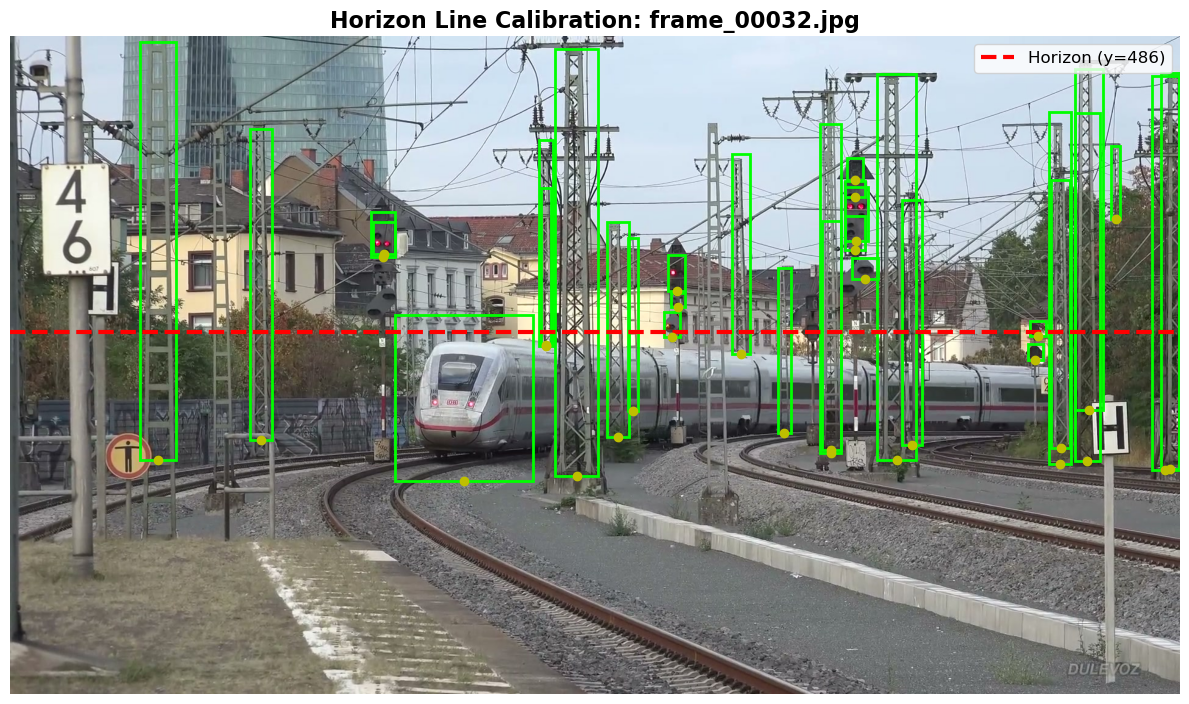

In [49]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. CONFIGURATION ---
# Pick one of the images that threw 'inf' errors
TEST_IMAGE_NAME = "frame_00032.jpg"  

# 🛑 THIS IS THE VARIABLE TO TUNE 🛑
# We start by assuming the horizon is exactly in the middle (0.5).
# If the red line is too low (cutting through far-away trains), lower this fraction (e.g., 0.3 or 0.2)
# to push the red line UP toward the top of the image.
HORIZON_RATIO = 0.45

# --- 2. FIND THE FILE ---
img_path = os.path.join(IMAGES_DIR, TEST_IMAGE_NAME)
label_name = TEST_IMAGE_NAME.rsplit('.', 1)[0] + '.txt'
label_path = os.path.join(LABELS_DIR, label_name)

# --- 3. VISUALIZATION ENGINE ---
if os.path.exists(img_path) and os.path.exists(label_path):
    # Read image and convert BGR to RGB for matplotlib
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w, _ = img.shape
    
    # Calculate where our tunable horizon line sits
    cy_horizon = img_h * HORIZON_RATIO
    
    # Create the plot
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img_rgb)
    
    # Draw the Horizon Line
    ax.axhline(y=cy_horizon, color='red', linewidth=3, linestyle='--', label=f'Horizon (y={int(cy_horizon)})')
    
    # Read the labels and draw bounding boxes
    with open(label_path, 'r') as f:
        for line in f.readlines():
            data = line.strip().split()
            if len(data) >= 5:
                # YOLO format: class, x_center, y_center, width, height (normalized)
                x_norm, y_norm, w_norm, h_norm = map(float, data[1:5])
                
                # Convert to absolute pixels
                box_w = w_norm * img_w
                box_h = h_norm * img_h
                box_x = (x_norm * img_w) - (box_w / 2.0)
                box_y = (y_norm * img_h) - (box_h / 2.0)
                
                # Draw the box
                rect = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                
                # Draw a dot at the bottom center (where the wheels touch the tracks)
                ax.plot((x_norm * img_w), box_y + box_h, 'yo', markersize=6)

    plt.title(f"Horizon Line Calibration: {TEST_IMAGE_NAME}", fontsize=16, fontweight='bold')
    plt.legend(loc='upper right', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
else:
    print(f"❌ Could not find {TEST_IMAGE_NAME} or its label in your dataset directories.")

In [48]:
import os
import cv2
import pandas as pd

# --- 1. DB CAMERA & HYBRID CONFIGURATION ---
F_PIXEL = 1200.0              # Needs tuning based on the specific Teledyne DB camera lens
REAL_TRAIN_HEIGHT = 4.0       # Average physical height of a train in meters
CAMERA_HEIGHT = 2.0           # Height of the camera above the tracks
HORIZON_RATIO = 0.45          # Your calibrated vanishing point

# The Hybrid Switch (in pixels)
# If a bounding box is taller than this, we trust the Ground Plane. 
# If it's smaller (far away), we trust Pinhole.
HYBRID_SWITCH_HEIGHT = 150.0  

# --- 2. PIPELINE EXECUTION ---
def evaluate_hybrid_distances(images_dir, labels_dir):
    results = []
    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    possible_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG']
    
    for label_file in label_files:
        img_name = next((label_file.replace('.txt', ext) for ext in possible_extensions 
                         if os.path.exists(os.path.join(images_dir, label_file.replace('.txt', ext)))), None)
        if not img_name: continue
            
        img_h, img_w, _ = cv2.imread(os.path.join(images_dir, img_name)).shape
        cy_horizon = img_h * HORIZON_RATIO  # Calibrated Horizon
        
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f.readlines():
                data = line.strip().split()
                if len(data) < 5: continue
                
                class_id = int(data[0])
                x_norm, y_norm, w_norm, h_norm = map(float, data[1:5])
                
                # Pixel conversions
                s_h = h_norm * img_h
                y_center = y_norm * img_h
                y_bottom = y_center + (s_h / 2.0)
                
                # --- CALCULATION 1: PINHOLE ---
                dist_pinhole = (F_PIXEL * REAL_TRAIN_HEIGHT) / s_h if s_h > 0 else float('inf')
                
                # --- CALCULATION 2: GROUND PLANE ---
                if y_bottom > cy_horizon:
                    dist_ground = (CAMERA_HEIGHT * F_PIXEL) / (y_bottom - cy_horizon)
                else:
                    dist_ground = float('inf')
                    
                # --- CALCULATION 3: THE HYBRID ESTIMATE ---
                # Default to Ground Plane for high accuracy, switch to Pinhole for distant stability
                if s_h >= HYBRID_SWITCH_HEIGHT and dist_ground != float('inf'):
                    final_dist = dist_ground
                    chosen_method = "Ground Plane"
                else:
                    final_dist = dist_pinhole
                    chosen_method = "Pinhole"
                
                results.append({
                    "image": img_name,
                    "bbox_height_px": round(s_h, 2),
                    "dist_pinhole_m": round(dist_pinhole, 2),
                    "dist_ground_m": round(dist_ground, 2),
                    "FINAL_DISTANCE_M": round(final_dist, 2),
                    "method_used": chosen_method
                })
                
    return pd.DataFrame(results)

# Run the evaluation
df_final = evaluate_hybrid_distances(IMAGES_DIR, LABELS_DIR)

print("\n--- 🚆 DB HYBRID DISTANCE PIPELINE ---")
print(df_final[['image', 'bbox_height_px', 'FINAL_DISTANCE_M', 'method_used']].head(15))


--- 🚆 DB HYBRID DISTANCE PIPELINE ---
                 image  bbox_height_px  FINAL_DISTANCE_M   method_used
0   frame_00000334.png         1078.25              4.04  Ground Plane
1   frame_00000241.png          240.20             22.50  Ground Plane
2   frame_00000241.png          431.14              7.46  Ground Plane
3      frame_00042.jpg           58.93             81.45       Pinhole
4      frame_00042.jpg           63.95             75.06       Pinhole
5      frame_00042.jpg          802.48              4.23  Ground Plane
6      frame_00042.jpg           48.53             98.91       Pinhole
7      frame_00042.jpg           62.81             76.42       Pinhole
8      frame_00042.jpg           64.88             73.98       Pinhole
9      frame_00042.jpg           49.32             97.32       Pinhole
10     frame_00042.jpg           63.00             76.19       Pinhole
11     frame_00042.jpg           48.43             99.11       Pinhole
12     frame_00042.jpg           52.60

In [50]:
import os
import cv2
import pandas as pd

# --- 1. DB STATION CCTV CONFIGURATION ---
F_PIXEL = 600.0               # Lower focal length for wide-angle CCTV
REAL_TRAIN_HEIGHT = 4.0       # Average height of DB train (ICE/Regio)
CAMERA_HEIGHT = 5.0           # CCTV cameras are mounted high up (adjust based on station)
HORIZON_RATIO = 0.45          # Your calibrated vanishing point 

# Hybrid Switch: Because it's CCTV, we trust Ground Plane for almost everything,
# unless the bounding box is incredibly small (very far down the track).
HYBRID_SWITCH_HEIGHT = 50.0  

# --- 2. PIPELINE EXECUTION ---
def evaluate_cctv_distances(images_dir, labels_dir):
    results = []
    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    possible_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG']
    
    for label_file in label_files:
        img_name = next((label_file.replace('.txt', ext) for ext in possible_extensions 
                         if os.path.exists(os.path.join(images_dir, label_file.replace('.txt', ext)))), None)
        if not img_name: continue
            
        img_h, img_w, _ = cv2.imread(os.path.join(images_dir, img_name)).shape
        cy_horizon = img_h * HORIZON_RATIO 
        
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f.readlines():
                data = line.strip().split()
                if len(data) < 5: continue
                
                class_id = int(data[0])
                x_norm, y_norm, w_norm, h_norm = map(float, data[1:5])
                
                s_h = h_norm * img_h
                y_center = y_norm * img_h
                y_bottom = y_center + (s_h / 2.0)
                
                # --- CALCULATION 1: PINHOLE (Less reliable on CCTV side-angles) ---
                dist_pinhole = (F_PIXEL * REAL_TRAIN_HEIGHT) / s_h if s_h > 0 else float('inf')
                
                # --- CALCULATION 2: GROUND PLANE (Highly reliable for fixed CCTV) ---
                if y_bottom > cy_horizon:
                    dist_ground = (CAMERA_HEIGHT * F_PIXEL) / (y_bottom - cy_horizon)
                else:
                    dist_ground = float('inf')
                    
                # --- CALCULATION 3: CCTV HYBRID LOGIC ---
                if s_h >= HYBRID_SWITCH_HEIGHT and dist_ground != float('inf'):
                    final_dist = dist_ground
                    chosen_method = "Ground Plane"
                else:
                    final_dist = dist_pinhole
                    chosen_method = "Pinhole"
                
                results.append({
                    "image": img_name,
                    "bbox_height_px": round(s_h, 2),
                    "FINAL_DISTANCE_M": round(final_dist, 2),
                    "method_used": chosen_method
                })
                
    return pd.DataFrame(results)

# Run the evaluation
df_final_cctv = evaluate_cctv_distances(IMAGES_DIR, LABELS_DIR)

print("\n--- 📹 DB STATION CCTV DISTANCE ESTIMATION ---")
print(df_final_cctv[['image', 'bbox_height_px', 'FINAL_DISTANCE_M', 'method_used']].head(15))


--- 📹 DB STATION CCTV DISTANCE ESTIMATION ---
                 image  bbox_height_px  FINAL_DISTANCE_M   method_used
0   frame_00000334.png         1078.25              5.05  Ground Plane
1   frame_00000241.png          240.20             28.13  Ground Plane
2   frame_00000241.png          431.14              9.33  Ground Plane
3      frame_00042.jpg           58.93             77.60  Ground Plane
4      frame_00042.jpg           63.95             58.65  Ground Plane
5      frame_00042.jpg          802.48              5.29  Ground Plane
6      frame_00042.jpg           48.53             49.45       Pinhole
7      frame_00042.jpg           62.81             81.74  Ground Plane
8      frame_00042.jpg           64.88             79.30  Ground Plane
9      frame_00042.jpg           49.32             48.66       Pinhole
10     frame_00042.jpg           63.00             55.49  Ground Plane
11     frame_00042.jpg           48.43             49.56       Pinhole
12     frame_00042.jpg        

In [ ]:
import os
import cv2
import numpy as np
from collections import deque

# --- 1. CONFIGURATION ---
OUTPUT_VIDEO_FILENAME = "db_station_analysis.mp4"
FPS = 10                       # Frames per second for the output video

# Calibrated CCTV Constants
F_PIXEL = 600.0               
REAL_TRAIN_HEIGHT = 4.0       
CAMERA_HEIGHT = 5.0           
HORIZON_RATIO = 0.45          
HYBRID_SWITCH_HEIGHT = 50.0  

# Temporal Smoothing Settings
SMOOTHING_WINDOW = 5          # Average distance over the last 5 frames
distance_history = {}         # Dictionary to hold rolling queues per class_id

# --- 2. PREPARE SEQUENTIAL FRAMES ---
# Get all image files and sort them chronologically
possible_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG')
all_images = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(possible_extensions)])

if not all_images:
    print("❌ No images found to process into a video.")
else:
    # Read the first frame to get video dimensions
    sample_img = cv2.imread(os.path.join(IMAGES_DIR, all_images[0]))
    frame_h, frame_w, _ = sample_img.shape
    cy_horizon = int(frame_h * HORIZON_RATIO)

    # Initialize the Video Writer (Using MP4V codec for high compatibility)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(OUTPUT_VIDEO_FILENAME, fourcc, FPS, (frame_w, frame_h))

    print(f"🎬 Processing {len(all_images)} frames into stabilized video...")

    # --- 3. VIDEO PROCESSING LOOP ---
    for img_name in all_images:
        img_path = os.path.join(IMAGES_DIR, img_name)
        frame = cv2.imread(img_path)
        if frame is None: continue
            
        # Draw the permanent mathematical Horizon Line (Bright Red)
        cv2.line(frame, (0, cy_horizon), (frame_w, cy_horizon), (0, 0, 255), 2, cv2.LINE_AA)
        cv2.putText(frame, "CALIBRATED HORIZON", (10, cy_horizon - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
        
        # Look for the matching YOLO text label
        label_name = img_name.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(LABELS_DIR, label_name)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if len(data) < 5: continue
                    
                    class_id = int(data[0])
                    x_norm, y_norm, w_norm, h_norm = map(float, data[1:5])
                    
                    # Convert to absolute pixel coordinates
                    box_w = int(w_norm * frame_w)
                    box_h = int(h_norm * frame_h)
                    x_min = int((x_norm * frame_w) - (box_w / 2.0))
                    y_min = int((y_norm * frame_h) - (box_h / 2.0))
                    y_bottom = y_min + box_h
                    
                    # --- DISTANCE CALCULATIONS ---
                    dist_pinhole = (F_PIXEL * REAL_TRAIN_HEIGHT) / box_h if box_h > 0 else float('inf')
                    
                    if y_bottom > cy_horizon:
                        dist_ground = (CAMERA_HEIGHT * F_PIXEL) / (y_bottom - cy_horizon)
                    else:
                        dist_ground = float('inf')
                        
                    # Select base method
                    if box_h >= HYBRID_SWITCH_HEIGHT and dist_ground != float('inf'):
                        raw_distance = dist_ground
                        method = "Ground"
                    else:
                        raw_distance = dist_pinhole
                        method = "Pinhole"
                    
                    # --- TEMPORAL SMOOTHING FILTER ---
                    if class_id search not in distance_history:
                        distance_history[class_id] = deque(maxlen=SMOOTHING_WINDOW)
                    
                    # Append raw calculation to the object's history
                    distance_history[class_id].append(raw_distance)
                    
                    # Calculate the moving average
                    smoothed_distance = sum(distance_history[class_id]) / len(distance_history[class_id])
                    
                    # --- VISUAL RENDERING ---
                    # Draw bounding box (Neon Green)
                    cv2.rectangle(frame, (x_min, y_min), (x_min + box_w, y_min + box_h), (0, 255, 0), 2)
                    
                    # Draw a contact point dot where wheels meet tracks
                    cv2.circle(frame, (int(x_norm * frame_w), y_bottom), 5, (0, 255, 255), -1)
                    
                    # Generate the text overlay
                    label_text = f"ID: {class_id} | Dist: {smoothed_distance:.2f}m ({method})"
                    
                    # Draw background text chassis for readability
                    (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                    cv2.rectangle(frame, (x_min, y_min - text_h - 10), (x_min + text_w, y_min), (0, 255, 0), -1)
                    cv2.putText(frame, label_text, (x_min, y_min - 6), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2, cv2.LINE_AA)

        # Save frame to the video compiler
        video_writer.write(frame)

    # Clean up hardware resources
    video_writer.release()
    cap.release() if 'cap' in locals() else None
    print(f"🎉 Video compilation complete! Saved as: {os.path.abspath(OUTPUT_VIDEO_FILENAME)}")